In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    finalNumber1: str
    finalNumber2: str

In [4]:
def add_node_1(state: AgentState) -> AgentState:
    """This node adds first two numbers"""

    state['finalNumber1'] = state['number1'] + state['number2']

    return state

def subtract_node_1(state: AgentState) -> AgentState:
    """This node substracts first two numbers"""

    state['finalNumber1'] = state['number1'] - state['number2']

    return state

def add_node_2(state: AgentState) -> AgentState:
    """This node adds next two numbers"""

    state['finalNumber2'] = state['number3'] + state['number4']

    return state

def subtract_node_2(state: AgentState) -> AgentState:
    """This node substracts next two numbers"""

    state['finalNumber2'] = state['number3'] - state['number4']

    return state

In [5]:
def decision_node_1(state: AgentState) -> AgentState:
    """This node decides the operation for number1 and number2"""
    
    if state['operation1'] == '+':
        return "addition_operation_1"
    
    elif state['operation1'] == '-':
        return "subtraction_operation_1"
    
def decision_node_2(state: AgentState) -> AgentState:
    """This node decides the operation for number3 and number4"""

    if state['operation2'] == '+':
        return "addition_operation_2"
    
    elif state['operation2'] == '-':
        return "subtraction_operation_2"

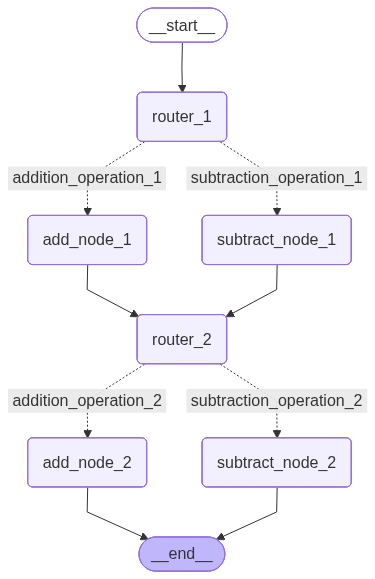

In [6]:
graph = StateGraph(AgentState)

graph.add_node("add_node_1", add_node_1)
graph.add_node("subtract_node_1", subtract_node_1)

graph.add_node("add_node_2", add_node_2)
graph.add_node("subtract_node_2", subtract_node_2)

graph.add_node("router_1", lambda state: state)
graph.add_node("router_2", lambda state: state)

graph.add_edge(START, "router_1")
graph.add_conditional_edges(
    "router_1",
    decision_node_1,
    {
        "addition_operation_1": "add_node_1",
        "subtraction_operation_1": "subtract_node_1"
    }
)

graph.add_edge("add_node_1", "router_2")
graph.add_edge("subtract_node_1", "router_2")

graph.add_conditional_edges(
    "router_2",
    decision_node_2,
    {
        "addition_operation_2": "add_node_2",
        "subtraction_operation_2": "subtract_node_2"
    }
)

graph.add_edge("add_node_2", END)
graph.add_edge("subtract_node_2", END)

app = graph.compile()

app

In [7]:
initial_state = AgentState(number1=10, number2=5, operation1="-", number3=7, number4=2, operation2="+")

app.invoke(initial_state)

{'number1': 10,
 'number2': 5,
 'number3': 7,
 'number4': 2,
 'operation1': '-',
 'operation2': '+',
 'finalNumber1': 5,
 'finalNumber2': 9}